# Método GET na tabela do IBGE: PIB regional 🤑
---
**Documentação DA API** 📖
*   https://apisidra.ibge.gov.br/home/ajuda
---
**Documentação das tabelas do IBGE** 📖
*   https://www.ibge.gov.br/acesso-informacao/dados-abertos.html
---

In [7]:
import requests
import pandas as pd
import json
from io import StringIO

#URL base da API
url = "https://apisidra.ibge.gov.br/values"


#Parâmetro T - qual a tabela vamos acessar
tabela = "/t/5938"    #PIB municipal


#Parametro N – para especificar níveis territoriais e suas unidades
nivel = "/n3/43"   #N6 município
                          #/all todos
                          #/4316808 Santa cruz do sul


#Parametro V -  o que queremos medir
medidas = "/v/37"     #Vamos medir o PIB
                        #37 PIB
                        #553 percentual

#Parâmetro P - período
periodo = "/p/all"  #/2021 para ano 2021
                    #/all para todos

#formato
formato = "?formato=json"

##Junta tudo para formar a URL de requisição
url+= tabela + nivel + medidas + periodo + formato
print("-----------URL de REquisição-------------")
print(url)


# Faz a requisição HTTP para a API
# Ou seja, envia a URL e recebe a resposta do servidor
response = requests.get(url)


# Converte a resposta da API (JSON em texto) para estrutura Python
data = response.json()


# Converte os dados em um DataFrame (tabela do pandas)
# data[1:] correção para remover o primeiro elemento (nome da coluna)
#OBS: Tratamento dos dados podem como este, geralmente são necessários
df = pd.DataFrame(data[1:])


df['V'] = pd.to_numeric(df['V'], errors='coerce')
# Converte a coluna 'V' para tipo numérico (inteiro ou float)
# errors='coerce' transforma valores inválidos em NaN
# isso evita erro em operações matemáticas como soma e média


df.head(50) ## mostra apenas os 50 primeiros
#print(df) ## Mostra todos os registros

-----------URL de REquisição-------------
https://apisidra.ibge.gov.br/values/t/5938/n3/43/v/37/p/all?formato=json


,NC,NN,MC,MN,V,D1C,D1N,D2C,D2N,D3C,D3N
0,3,Unidade da Federação,40,Mil Reais,98847211,43,Rio Grande do Sul,37,Produto Interno Bruto a preços correntes,2002,2002
1,3,Unidade da Federação,40,Mil Reais,119325399,43,Rio Grande do Sul,37,Produto Interno Bruto a preços correntes,2003,2003
2,3,Unidade da Federação,40,Mil Reais,131192206,43,Rio Grande do Sul,37,Produto Interno Bruto a preços correntes,2004,2004
3,3,Unidade da Federação,40,Mil Reais,136362769,43,Rio Grande do Sul,37,Produto Interno Bruto a preços correntes,2005,2005
4,3,Unidade da Federação,40,Mil Reais,147622599,43,Rio Grande do Sul,37,Produto Interno Bruto a preços correntes,2006,2006
5,3,Unidade da Federação,40,Mil Reais,168009752,43,Rio Grande do Sul,37,Produto Interno Bruto a preços correntes,2007,2007
6,3,Unidade da Federação,40,Mil Reais,190229822,43,Rio Grande do Sul,37,Produto Interno Bruto a preços correntes,2008,2008
7,3,Unidade da Federação,40,Mil Reais,204344940,43,Rio Grande do Sul,37,Produto Interno Bruto a preços correntes,2009,2009
8,3,Unidade da Federação,40,Mil Reais,241249164,43,Rio Grande do Sul,37,Produto Interno Bruto a preços correntes,2010,2010
9,3,Unidade da Federação,40,Mil Reais,265056416,43,Rio Grande do Sul,37,Produto Interno Bruto a preços correntes,2011,2011


# Agora vamos utilizar os dados que extraímos da API para calcular uma média !

In [8]:

total = df['V'].sum() ##Soma coluna 'V'
print("------------Total pib periodo-------------")
print(total)

qtd_muni = df['V'].count()
print("------------Qtd Linhas Analisadas-------------")
print(qtd_muni)

media = round(total / qtd_muni,2) #ajusta para 2 casas decimais

print("------------Média pib periodo-------------")
print(media)

------------Total pib periodo-------------
7129712959
------------Qtd Linhas Analisadas-------------
22
------------Média pib periodo-------------
324077861.77


# Continuando a aula de arquivo, vamos criar um arquivo na extrutura de pastas!

In [4]:
with open("dados_ibge.txt", "w", encoding="utf-8") as f:
    f.write("-   Média do PIB em anos: "+str(media))
    f.write("\n-   Json estruturado:\n")
    f.write(json.dumps(data, indent=4, ensure_ascii=False))
    f.write("\n-   Json Original:\n")
    f.write(response.text)

# Agora vamos baixar o arquivo !!!

In [ ]:
from google.colab import files

files.download("dados_ibge.txt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# O que mais podemos fazer ?

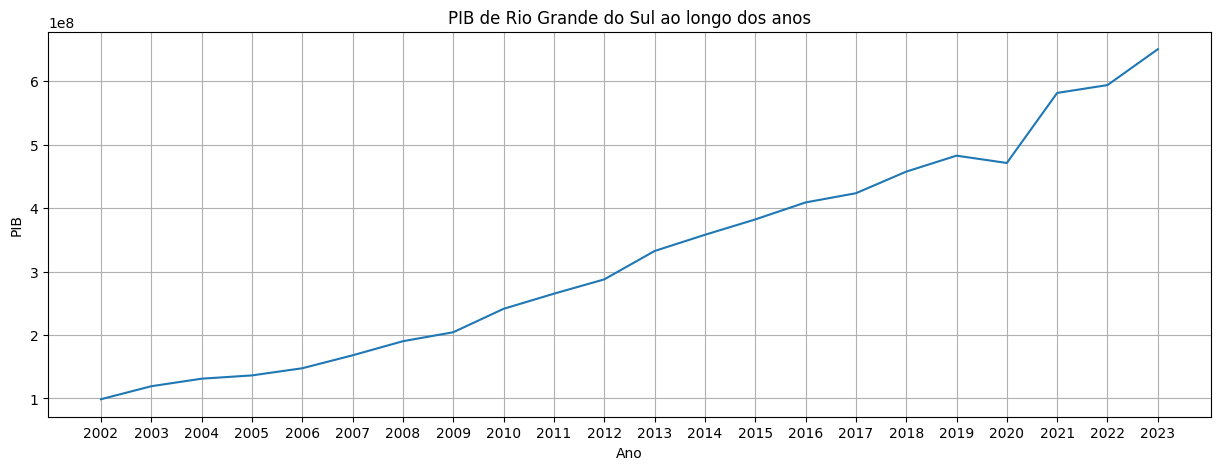

In [9]:
import matplotlib.pyplot as plt

# Converter coluna de valor para número
df['V'] = pd.to_numeric(df['V'], errors='coerce')

# Converter ano para número
df['D3C'] = pd.to_numeric(df['D3C'], errors='coerce')

# Criando gráfico de linhas
plt.figure(figsize=(15,5))

plt.plot(df['D3C'], df['V'])

# Pega o nome do primeiro município da tabela
municipio = df['D1N'].iloc[0]
plt.xticks(df['D3C'])
# Título e legendas
plt.title(f'PIB de {municipio} ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('PIB')

# Grade no gráfico
plt.grid(True)

# Exibir gráfico
plt.show()

In [6]:
top10 = df.sort_values(by='V', ascending=False).head(10)
print(top10[['D1N','D3C', 'V']])

                       D1N   D3C         V
21  Santa Cruz do Sul (RS)  2023  13396618
20  Santa Cruz do Sul (RS)  2022  11189591
18  Santa Cruz do Sul (RS)  2020  10489874
17  Santa Cruz do Sul (RS)  2019   9830488
19  Santa Cruz do Sul (RS)  2021   9815201
16  Santa Cruz do Sul (RS)  2018   9499328
15  Santa Cruz do Sul (RS)  2017   8364420
14  Santa Cruz do Sul (RS)  2016   8180550
12  Santa Cruz do Sul (RS)  2014   7984011
13  Santa Cruz do Sul (RS)  2015   7764004


## Testando outra API

In [3]:


#URL base da API
url_filmes = "https://www.omdbapi.com/?t="
nomefilme = "Lord+of+the+rings"
chave = "&apikey=cc344897"
url_filmes_fim = url_filmes + nomefilme + chave
print(url_filmes_fim)

response = requests.get(url_filmes_fim)
# Converte a resposta da API (JSON em texto) para estrutura Python
data_movie = response.json()


print(json.dumps(data_movie, indent=4, ensure_ascii=False))

https://www.omdbapi.com/?t=Lord+of+the+rings&apikey=cc344897
{
    "Title": "The Lord of the Rings: The Fellowship of the Ring",
    "Year": "2001",
    "Rated": "PG-13",
    "Released": "19 Dec 2001",
    "Runtime": "178 min",
    "Genre": "Adventure, Drama, Fantasy",
    "Director": "Peter Jackson",
    "Writer": "J.R.R. Tolkien, Fran Walsh, Philippa Boyens",
    "Actors": "Elijah Wood, Ian McKellen, Orlando Bloom",
    "Plot": "A meek Hobbit from the Shire and eight companions set out on a journey to destroy the powerful One Ring and save Middle-earth from the Dark Lord Sauron.",
    "Language": "English, Sindarin",
    "Country": "New Zealand, United States",
    "Awards": "Won 4 Oscars. 126 wins & 127 nominations total",
    "Poster": "https://m.media-amazon.com/images/M/MV5BNzIxMDQ2YTctNDY4MC00ZTRhLTk4ODQtMTVlOWY4NTdiYmMwXkEyXkFqcGc@._V1_QL75_UX380_CR0,1,380,562_.jpg",
    "Ratings": [
        {
            "Source": "Internet Movie Database",
            "Value": "8.9/10"
      